#DATA MINING PROJECT




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
vax_df = pd.read_csv("/content/global-vaccination-coverage.csv")
mort_df = pd.read_csv("/content/infant_mortality .csv")
print("Vax shape:", vax_df.shape)
print("Mort shape:", mort_df.shape)

Vax shape: (9203, 12)
Mort shape: (38515, 34)


In [4]:
print(vax_df.head())

        Entity Code  Year  \
0  Afghanistan  AFG  2007   
1  Afghanistan  AFG  2008   
2  Afghanistan  AFG  2009   
3  Afghanistan  AFG  2010   
4  Afghanistan  AFG  2011   

   Share of one-year-olds who have had three doses of the hepatitis B vaccine  \
0                                               63.0                            
1                                               64.0                            
2                                               63.0                            
3                                               66.0                            
4                                               68.0                            

   Share of one-year-olds vaccinated against Haemophilus influenzae type b  \
0                                                NaN                         
1                                                NaN                         
2                                               63.0                         
3                         

In [5]:
print(mort_df.head())

    IndicatorCode                                          Indicator  \
0  MDG_0000000001  Infant mortality rate (probability of dying be...   
1  MDG_0000000001  Infant mortality rate (probability of dying be...   
2  MDG_0000000001  Infant mortality rate (probability of dying be...   
3  MDG_0000000001  Infant mortality rate (probability of dying be...   
4  MDG_0000000001  Infant mortality rate (probability of dying be...   

  ValueType ParentLocationCode   ParentLocation Location type  \
0   numeric                EUR           Europe       Country   
1   numeric                EUR           Europe       Country   
2   numeric                EUR           Europe       Country   
3   numeric                EUR           Europe       Country   
4   numeric                WPR  Western Pacific       Country   

  SpatialDimValueCode    Location Period type  Period  ...  FactValueUoM  \
0                 SMR  San Marino        Year    2023  ...           NaN   
1                 SMR  S

In [7]:
# Rename columns in vax_df
vax_df = vax_df.rename(columns={
    "Entity": "Country",
    "Code": "ISO_Code",
    "Year": "Year",
    "Share of one-year-olds who have had three doses of the hepatitis B vaccine": "HepB_3dose",
    "Share of one-year-olds vaccinated against Haemophilus influenzae type b": "Hib_3dose",
    "Share of one-year-olds who have had the one dose of the inactivated polio vaccine": "Polio_1dose",
    "Share of one-year-olds who have had one dose of the measles vaccine": "Measles_1dose",
    "Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine": "Pneumo_3dose",
    "Share of one-year-olds who have had three doses of the polio vaccine": "Polio_3dose",
    "Share of one-year-olds vaccinated against rubella": "Rubella_1dose",
    "Share of one-year-olds vaccinated against rotavirus": "Rotavirus_1dose",
    "Share of one-year-olds who have had three doses of the diphtheria, tetanus and pertussis vaccine": "DTP_3dose"
})

In [8]:
print(vax_df.head())

       Country ISO_Code  Year  HepB_3dose  Hib_3dose  Polio_1dose  \
0  Afghanistan      AFG  2007        63.0        NaN          NaN   
1  Afghanistan      AFG  2008        64.0        NaN          NaN   
2  Afghanistan      AFG  2009        63.0       63.0          NaN   
3  Afghanistan      AFG  2010        66.0       66.0          NaN   
4  Afghanistan      AFG  2011        68.0       68.0          NaN   

   Measles_1dose  Pneumo_3dose  Polio_3dose  Rubella_1dose  Rotavirus_1dose  \
0           55.0           NaN         63.0            NaN              NaN   
1           59.0           NaN         64.0            NaN              NaN   
2           60.0           NaN         63.0            NaN              NaN   
3           62.0           NaN         66.0            NaN              NaN   
4           64.0           NaN         68.0            NaN              NaN   

   DTP_3dose  
0       63.0  
1       64.0  
2       63.0  
3       66.0  
4       68.0  


In [9]:
# Rename columns in mort_df
mort_df = mort_df.rename(columns={
    'Location': 'Country',
    'SpatialDimValueCode': 'ISO_Code',
    'Period': 'Year',
    'Value': 'Infant_Mortality_Rate'
})

In [10]:
# Clean mort_df similarly, then merge
merged_df = pd.merge(vax_df[['Country', 'ISO_Code', 'Year', "Measles_1dose"]],
                     mort_df[['Country', 'ISO_Code', 'Year', 'Infant_Mortality_Rate']],
                     on=['Country', 'ISO_Code', 'Year'], how='inner')
print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (21216, 5)
       Country ISO_Code  Year  Measles_1dose Infant_Mortality_Rate
0  Afghanistan      AFG  2007           55.0      82.2 [76.3-88.8]
1  Afghanistan      AFG  2007           55.0      86.7 [80.6-93.2]
2  Afghanistan      AFG  2007           55.0      90.9 [84.2-98.0]
3  Afghanistan      AFG  2008           59.0      79.0 [73.0-85.4]
4  Afghanistan      AFG  2008           59.0      83.3 [77.3-89.8]


# **DATA CLEANING**

# **VACCINATION**

In [19]:
vax_df.isnull().sum()

,0
Country,0
ISO_Code,1029
Year,0
HepB_3dose,3559
Hib_3dose,4439
Polio_1dose,7146
Measles_1dose,155
Pneumo_3dose,6943
Polio_3dose,24
Rubella_1dose,3722


In [21]:
# Check total missing values in the dataset
total_missing = vax_df.isnull().sum().sum()
print("Total missing values",total_missing)

Total missing values 34530


In [22]:
# Check missing data percentage
percentage_missing_values =(vax_df.isnull().mean() * 100).round(2)
print("percentage missing values", percentage_missing_values)

percentage missing values Country             0.00
ISO_Code           11.18
Year                0.00
HepB_3dose         38.67
Hib_3dose          48.23
Polio_1dose        77.65
Measles_1dose       1.68
Pneumo_3dose       75.44
Polio_3dose         0.26
Rubella_1dose      40.44
Rotavirus_1dose    81.32
DTP_3dose           0.32
dtype: float64


In [23]:
# Shape
print("Number of rows:", vax_df.shape[0], ", Number of columns:", vax_df.shape[1])

Number of rows: 9203 , Number of columns: 12


In [29]:
# Drop columns with more than 50% missing values
threshold = len(vax_df) * 0.5
df_cleaned = vax_df.dropna(thresh=threshold, axis=1)
vax_df_clean = df_cleaned
print("Vax unique keys:", vax_df_clean.shape[0])

Vax unique keys: 9203


In [30]:
# Fill missing numeric values (vaccination rates) with column means

# Select vaccination columns (all columns after Country, ISO_Code, Year)
vaccine_cols = df_cleaned.columns[3:]

# Fill missing values with column means
df_cleaned[vaccine_cols] = df_cleaned[vaccine_cols].fillna(df_cleaned[vaccine_cols].mean())

/tmp/ipython-input-3330196927.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[vaccine_cols] = df_cleaned[vaccine_cols].fillna(df_cleaned[vaccine_cols].mean())


# **INFANT MORTALITY**

In [31]:
# Remove duplicates in mort datasets BEFORE merging
merge_keys = ['Country', 'ISO_Code', 'Year']
mort_df_clean = mort_df.drop_duplicates(subset=merge_keys).copy()

print("Mort unique keys:", mort_df_clean.shape[0])

Mort unique keys: 12967


In [32]:
# Merge deduplicated data
merged_df = pd.merge(
    vax_df_clean[merge_keys + ["Measles_1dose"]],
    mort_df_clean[merge_keys + ['Infant_Mortality_Rate']],  # Fix column name
    on=merge_keys, how='inner'
)
print("Clean merged shape:", merged_df.shape)
print(merged_df.head(10))
print("NaN Infant rates:", merged_df['Infant_Mortality_Rate'].isna().sum())

Clean merged shape: (7072, 5)
       Country ISO_Code  Year  Measles_1dose Infant_Mortality_Rate
0  Afghanistan      AFG  2007           55.0      82.2 [76.3-88.8]
1  Afghanistan      AFG  2008           59.0      79.0 [73.0-85.4]
2  Afghanistan      AFG  2009           60.0      75.8 [69.8-82.3]
3  Afghanistan      AFG  2010           62.0      72.8 [66.7-79.4]
4  Afghanistan      AFG  2011           64.0      70.0 [63.6-76.6]
5  Afghanistan      AFG  2012           59.0      67.2 [60.9-74.1]
6  Afghanistan      AFG  2013           57.0      64.7 [58.2-71.8]
7  Afghanistan      AFG  2014           60.0      62.3 [55.7-69.7]
8  Afghanistan      AFG  2015           62.0      60.3 [53.2-67.9]
9  Afghanistan      AFG  2016           64.0      58.3 [50.7-66.4]
NaN Infant rates: 0


In [48]:
print("Raw mort_df shape:", mort_df.shape)
print("Non-null FactValueNumeric:", mort_df['FactValueNumeric'].notna().sum())

# Filter ONLY infant mortality records + select key columns
mort_infant = mort_df[mort_df['Indicator'].str.contains('Infant mortality', na=False)].copy()

# Use FactValueNumeric as the actual rate (Infant_Mortality_Rate was empty)
mort_infant['Infant_Mortality_Rate'] = mort_infant['FactValueNumeric']

# Select ONLY needed columns
mort_final = mort_infant[['Country', 'ISO_Code', 'Year', 'Infant_Mortality_Rate']].drop_duplicates()
mort_final = merged_df.dropna(subset=['Infant_Mortality_Rate'])

print("FIXED Mort shape:", mort_final.shape)
print("Mort sample:")

mort_final['Infant_Mortality_Rate'] = (
    mort_final['Infant_Mortality_Rate']
        .str.extract(r'(^\d+\.?\d*)', expand=False)
        .astype(float)
)
print(mort_final.head())
print("\nIndia data:", mort_final[mort_final['Country'] == 'India'].head())

Raw mort_df shape: (38515, 34)
Non-null FactValueNumeric: 38515
FIXED Mort shape: (7072, 5)
Mort sample:
       Country ISO_Code  Year  Measles_1dose  Infant_Mortality_Rate
0  Afghanistan      AFG  2007           55.0                   82.2
1  Afghanistan      AFG  2008           59.0                   79.0
2  Afghanistan      AFG  2009           60.0                   75.8
3  Afghanistan      AFG  2010           62.0                   72.8
4  Afghanistan      AFG  2011           64.0                   70.0

India data:      Country ISO_Code  Year  Measles_1dose  Infant_Mortality_Rate
3026   India      IND  2004           64.0                   58.0
3027   India      IND  2005           68.0                   55.8
3028   India      IND  2006           69.0                   54.0
3029   India      IND  2007           70.0                   51.9
3030   India      IND  2008           72.0                   49.9


# **Focused Analysis on Measles Vaccine Coverage**

In [35]:
df_measles = df_cleaned[['Country', 'ISO_Code', 'Year', 'Measles_1dose']].copy()
df_measles.rename(columns={'Measles_1dose': 'Measles_Vaccine_Coverage'}, inplace=True)
# Drop rows with missing measles data
df_measles.dropna(subset=['Measles_Vaccine_Coverage'], inplace=True)

In [36]:
df_measles.head(50)

,Country,ISO_Code,Year,Measles_Vaccine_Coverage
0,Afghanistan,AFG,2007,55.000000
1,Afghanistan,AFG,2008,59.000000
2,Afghanistan,AFG,2009,60.000000
3,Afghanistan,AFG,2010,62.000000
4,Afghanistan,AFG,2011,64.000000
5,Afghanistan,AFG,2012,59.000000
6,Afghanistan,AFG,2013,57.000000
7,Afghanistan,AFG,2014,60.000000
8,Afghanistan,AFG,2015,62.000000
9,Afghanistan,AFG,2016,64.000000


# **Visualization: Trends for Selected Countries (VACCINATION)**

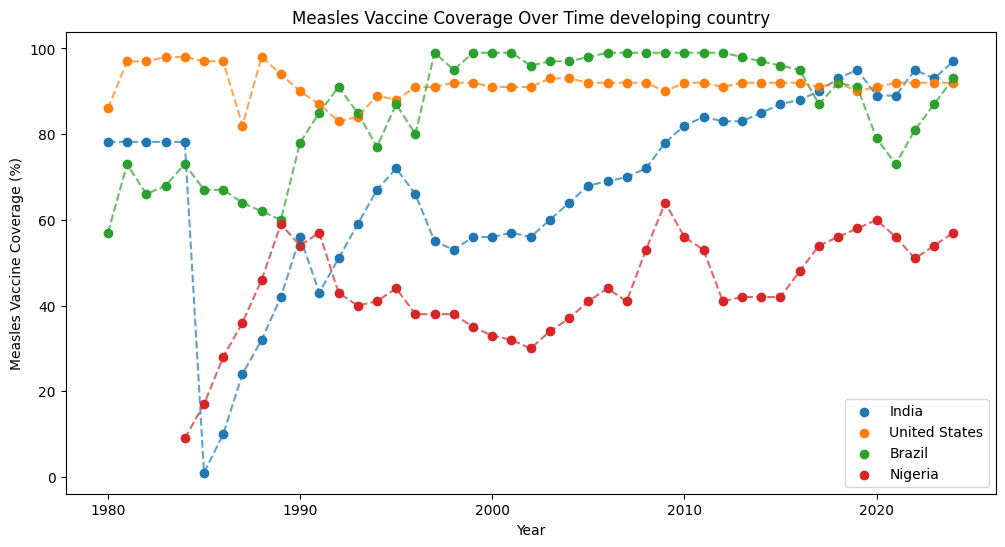

In [37]:
countries_to_plot = ['India', 'United States', 'Brazil', 'Nigeria']
plt.figure(figsize=(12,6))

for country in countries_to_plot:
    country_data = df_measles[df_measles['Country'] == country].sort_values('Year')
    plt.scatter(country_data['Year'], country_data['Measles_Vaccine_Coverage'], label=country)
    plt.plot(country_data['Year'], country_data['Measles_Vaccine_Coverage'], linestyle='--', alpha=0.7)



plt.xlabel("Year")
plt.ylabel("Measles Vaccine Coverage (%)")
plt.title("Measles Vaccine Coverage Over Time developing country")
plt.legend()
plt.show()

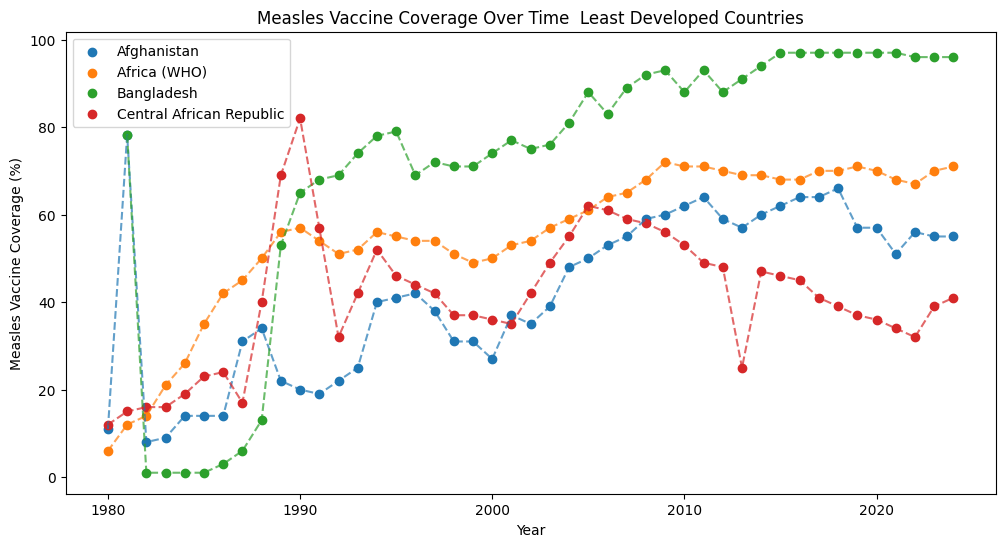

In [38]:
countries_to_plot = ['Afghanistan', 'Africa (WHO)', 'Bangladesh', 'Central African Republic']
plt.figure(figsize=(12,6))

for country in countries_to_plot:
    country_data = df_measles[df_measles['Country'] == country].sort_values('Year')
    plt.scatter(country_data['Year'], country_data['Measles_Vaccine_Coverage'], label=country)
    plt.plot(country_data['Year'], country_data['Measles_Vaccine_Coverage'], linestyle='--', alpha=0.7)



plt.xlabel("Year")
plt.ylabel("Measles Vaccine Coverage (%)")
plt.title("Measles Vaccine Coverage Over Time  Least Developed Countries")
plt.legend()
plt.show()

# **GLOBAL REPRESENTATION (VACCINATION)**

In [39]:
# Asia
asia_countries = [
    'India', 'China', 'Japan', 'Bangladesh', 'Pakistan', 'Afghanistan',
    'Nepal', 'Bhutan', 'Sri Lanka', 'Maldives', 'Indonesia', 'Malaysia',
    'Thailand', 'Vietnam', 'Myanmar', 'Philippines', 'South Korea',
    'North Korea', 'Singapore', 'Saudi Arabia', 'UAE', 'Qatar', 'Bahrain',
    'Iran', 'Iraq', 'Syria', 'Jordan', 'Lebanon', 'Turkey', 'Yemen'
]

# Africa
africa_countries = [
    'Nigeria', 'Kenya', 'Ethiopia', 'Egypt', 'South Africa', 'Ghana',
    'Algeria', 'Uganda', 'Sudan', 'Chad', 'Niger', 'Morocco', 'Tunisia',
    'Tanzania', 'Zimbabwe', 'Central African Republic', 'Cameroon',
    'Angola', 'Mali', 'Senegal', 'Africa'
]

# Europe
europe_countries = [
    'United Kingdom', 'Germany', 'France', 'Italy', 'Spain', 'Netherlands',
    'Belgium', 'Sweden', 'Norway', 'Finland', 'Poland', 'Greece',
    'Denmark', 'Austria', 'Portugal'
]

# North America
north_america_countries = [
    'United States of America', 'Canada', 'Mexico'
]

# South America
south_america_countries = [
    'Brazil', 'Argentina', 'Peru', 'Chile', 'Colombia', 'Uruguay'
]

# Oceania
oceania_countries = [
    'Australia', 'New Zealand', 'Fiji', 'Papua New Guinea'
]

def assign_continent(country):
    if country in asia_countries:
        return "Asia"
    elif country in africa_countries:
        return "Africa"
    elif country in europe_countries:
        return "Europe"
    elif country in north_america_countries:
        return "North America"
    elif country in south_america_countries:
        return "South America"
    elif country in oceania_countries:
        return "Oceania"
    else:
        return "Other"

df_measles['Continent'] = df_measles['Country'].apply(assign_continent)

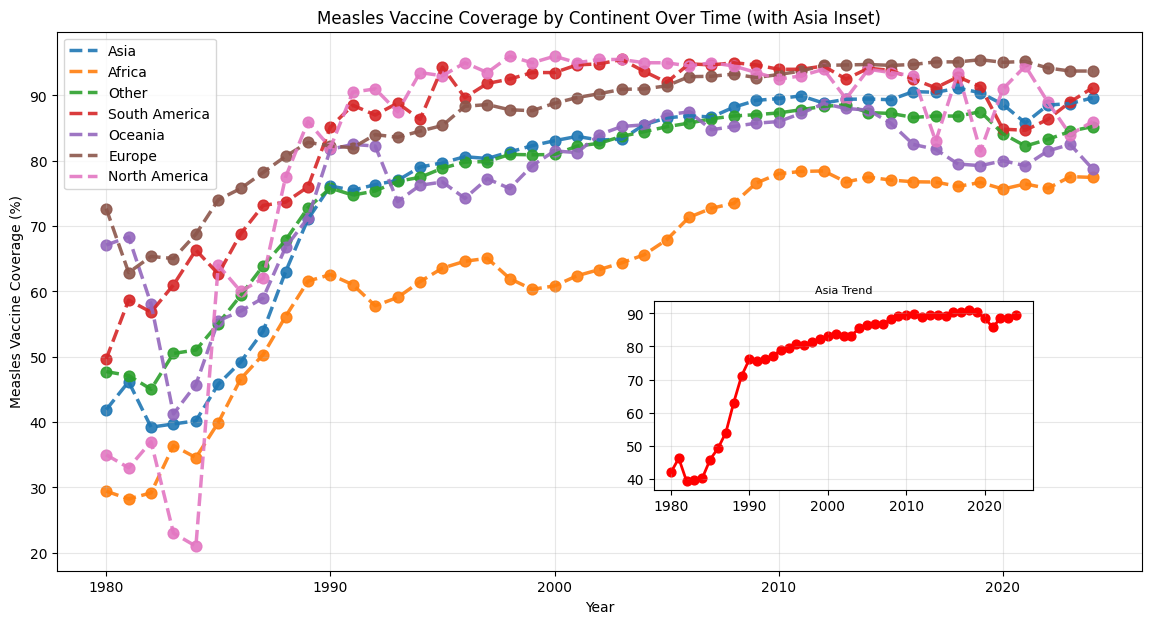

In [40]:
fig, ax = plt.subplots(figsize=(14,7))

# Main Continent Plot
for cont in df_measles['Continent'].unique():
    cont_data = df_measles[df_measles['Continent'] == cont]
    cont_yearly = cont_data.groupby('Year')['Measles_Vaccine_Coverage'].mean().reset_index()
    ax.scatter(cont_yearly['Year'], cont_yearly['Measles_Vaccine_Coverage'], s=60, alpha=0.9)
    ax.plot(cont_yearly['Year'], cont_yearly['Measles_Vaccine_Coverage'],
            linestyle='--', linewidth=2.5, alpha=0.9, label=cont)

ax.set_xlabel("Year")
ax.set_ylabel("Measles Vaccine Coverage (%)")
ax.set_title("Measles Vaccine Coverage by Continent Over Time (with Asia Inset)")
ax.grid(alpha=0.3)
ax.legend()

# Inset for Asia
inset = ax.inset_axes([0.55, 0.15, 0.35, 0.35])
asia = df_measles[df_measles['Continent']=="Asia"]
asia_yearly = asia.groupby('Year')['Measles_Vaccine_Coverage'].mean().reset_index()

inset.plot(asia_yearly['Year'], asia_yearly['Measles_Vaccine_Coverage'],
           linewidth=2, color="red")
inset.scatter(asia_yearly['Year'], asia_yearly['Measles_Vaccine_Coverage'],
              s=40, color="red")

inset.set_title("Asia Trend", fontsize=8)
inset.grid(alpha=0.3)

plt.show()


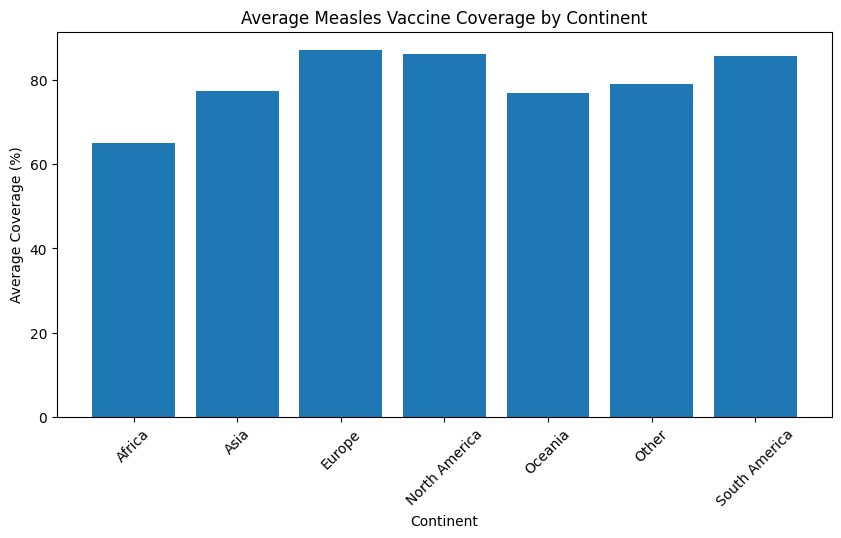

In [42]:
continent_avg = df_measles.groupby('Continent')['Measles_Vaccine_Coverage'].mean()

plt.figure(figsize=(10,5))
plt.bar(continent_avg.index, continent_avg.values)
plt.xlabel("Continent")
plt.ylabel("Average Coverage (%)")
plt.title("Average Measles Vaccine Coverage by Continent")
plt.xticks(rotation=45)
plt.show()

# **Graphs For Infant_Mortality**

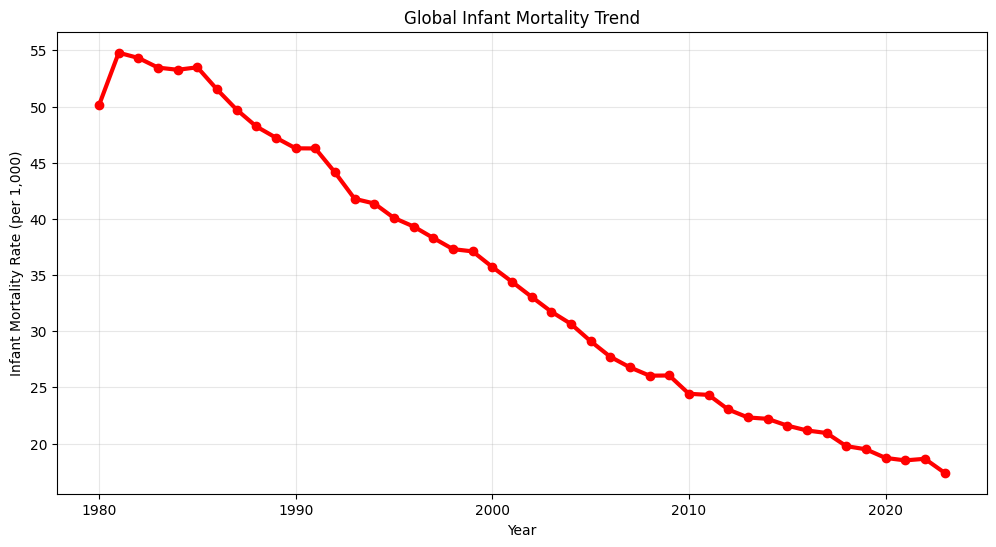

In [49]:
#Global infant mortality over time
yearly_mort = mort_final.groupby('Year')['Infant_Mortality_Rate'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_mort.index, yearly_mort.values, marker='o', linewidth=3, color='red')
plt.xlabel('Year')
plt.ylabel('Infant Mortality Rate (per 1,000)')
plt.title('Global Infant Mortality Trend')
plt.grid(alpha=0.3)
plt.show()

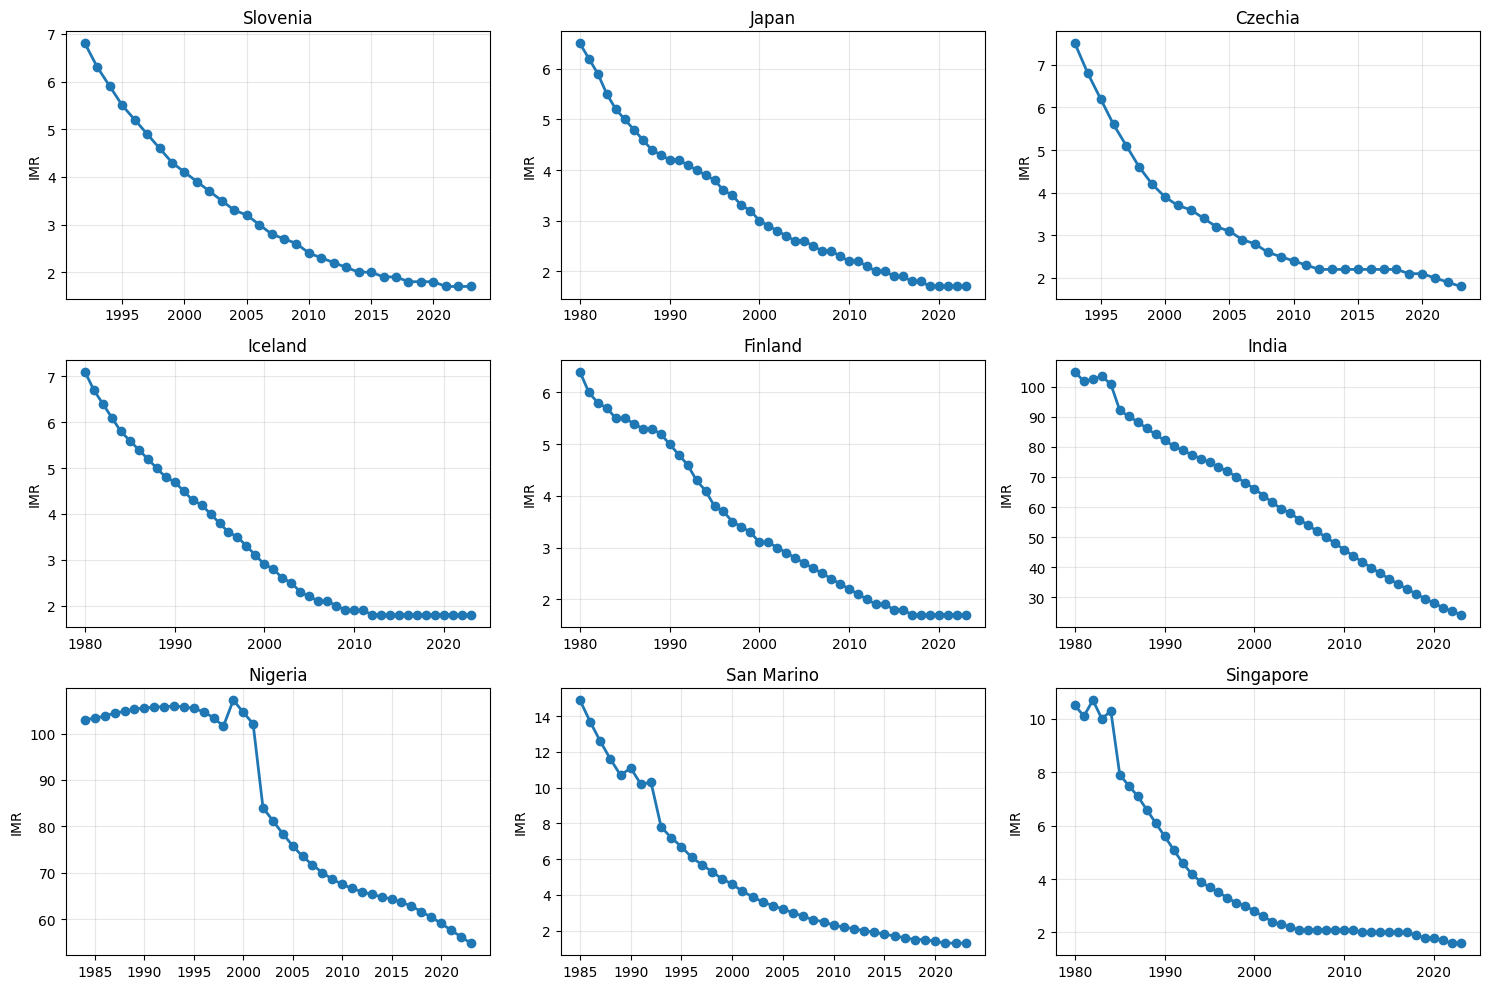

In [50]:
# Top countries
focus_countries = ['India', 'Nigeria', 'San Marino', 'Singapore']
top_countries = mort_final.groupby('Country')['Infant_Mortality_Rate'].mean().nsmallest(5).index

plt.figure(figsize=(15, 10))
for i, country in enumerate(top_countries.tolist() + focus_countries, 1):
    country_data = mort_final[mort_final['Country'] == country]
    yearly = country_data.groupby('Year')['Infant_Mortality_Rate'].mean()

    plt.subplot(3, 3, i)
    plt.plot(yearly.index, yearly.values, marker='o', linewidth=2)
    plt.title(country)
    plt.ylabel('IMR')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

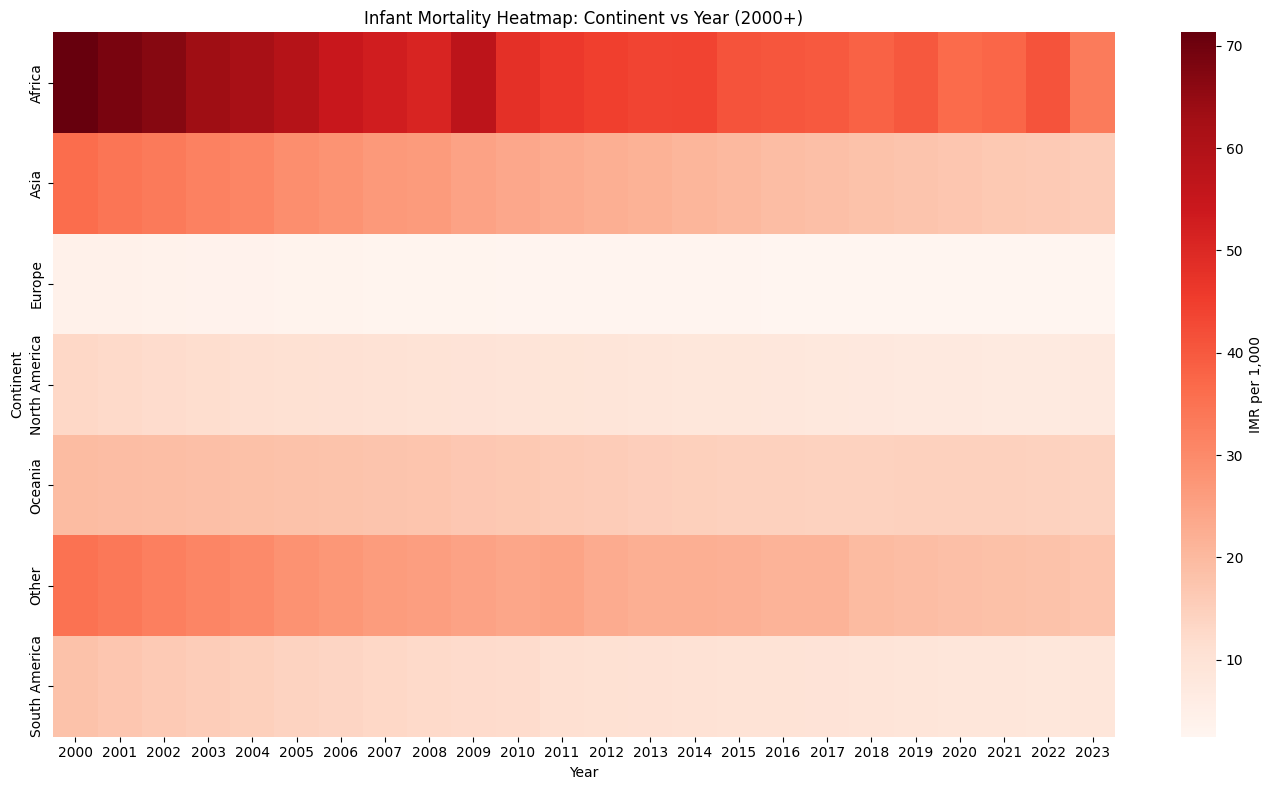

In [55]:
# Make sure Continent column exists
mort_final['Continent'] = mort_final['Country'].apply(assign_continent)

# Filter for recent years (2000+)
recent_mort_2000 = mort_final[mort_final['Year'] >= 2000]

# Create pivot table: rows = Continent, columns = Year
pivot_mort = (
    recent_mort_2000
    .groupby(['Continent', 'Year'])['Infant_Mortality_Rate']
    .mean()
    .unstack(fill_value=0)
)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_mort,
    annot=False,
    cmap='Reds',
    cbar_kws={'label': 'IMR per 1,000'}
)
plt.title('Infant Mortality Heatmap: Continent vs Year (2000+)')
plt.xlabel('Year')
plt.ylabel('Continent')
plt.tight_layout()
plt.show()

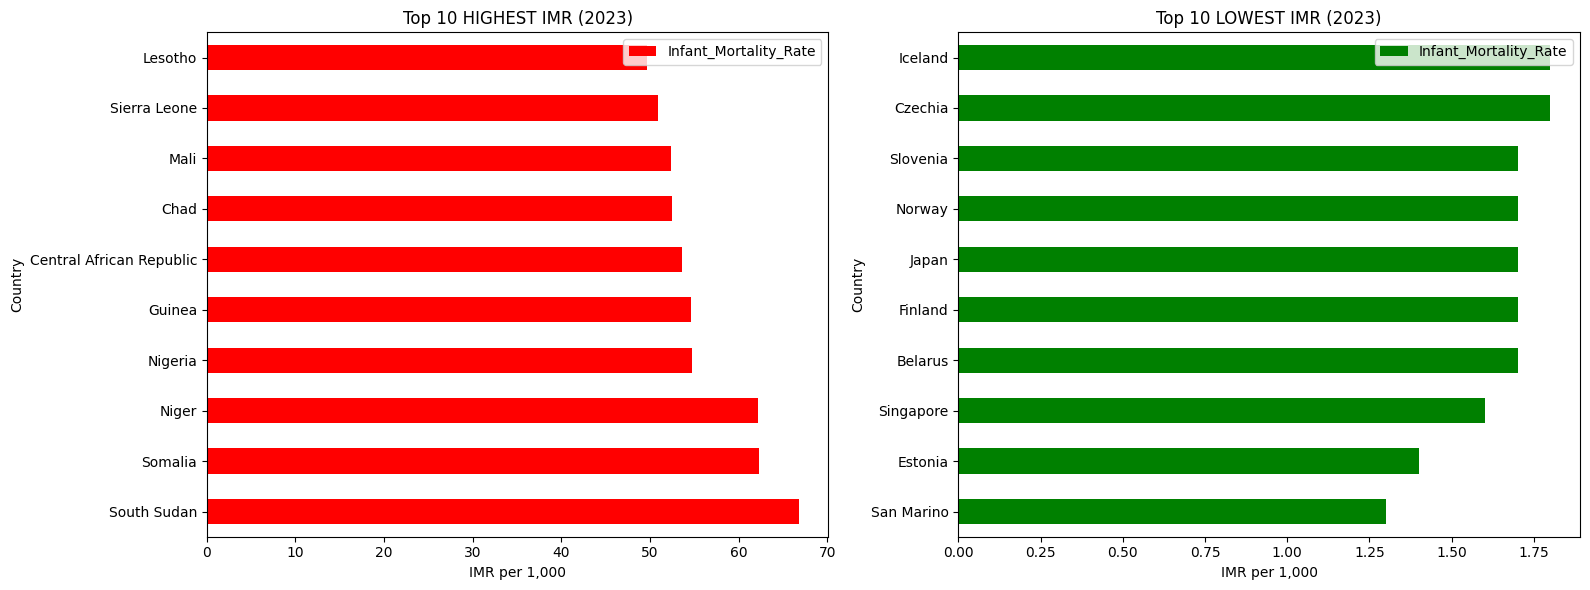

In [56]:
year_2023 = mort_final[mort_final['Year'] == 2023]
top10_high = year_2023.nlargest(10, 'Infant_Mortality_Rate')
top10_low = year_2023.nsmallest(10, 'Infant_Mortality_Rate')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top10_high.plot(x='Country', y='Infant_Mortality_Rate', kind='barh', ax=ax1, color='red')
ax1.set_title('Top 10 HIGHEST IMR (2023)')
ax1.set_xlabel('IMR per 1,000')

top10_low.plot(x='Country', y='Infant_Mortality_Rate', kind='barh', ax=ax2, color='green')
ax2.set_title('Top 10 LOWEST IMR (2023)')
ax2.set_xlabel('IMR per 1,000')

plt.tight_layout()
plt.show()

# **COMBINE OF BOTH DATA**

   Measles_1dose  Infant_Mortality_Rate
3           62.0                   72.8
4           64.0                   70.0
5           59.0                   67.2
6           57.0                   64.7
7           60.0                   62.3
Country                   object
ISO_Code                  object
Year                       int64
Measles_1dose            float64
Infant_Mortality_Rate    float64
Continent                 object
dtype: object


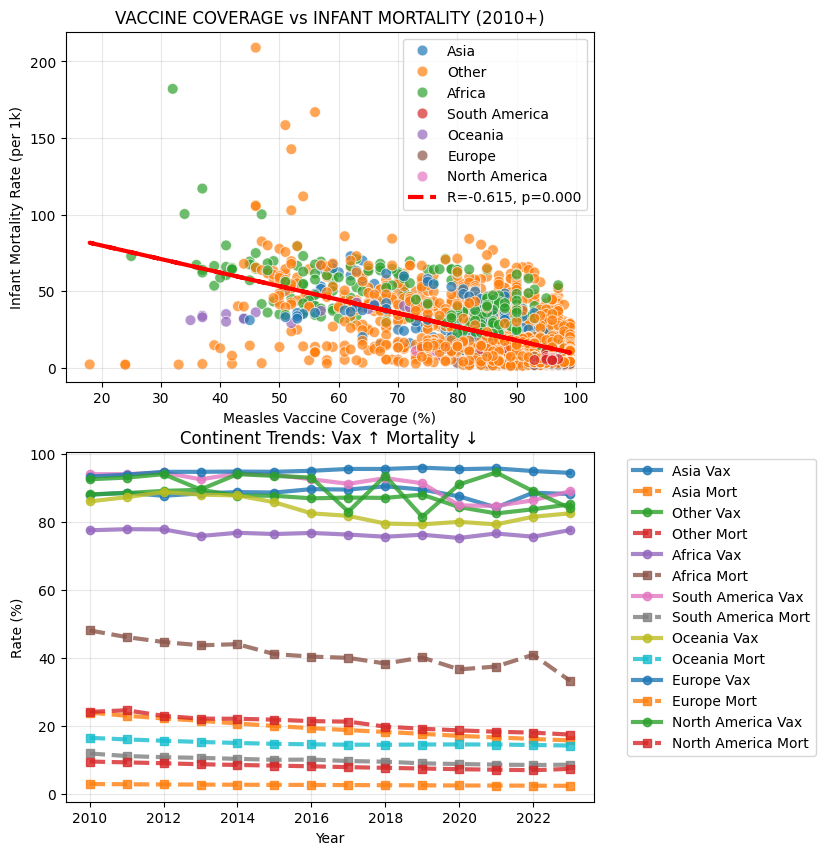

In [80]:
# Keep only the leading numeric part, drop the range in brackets
merged_clean['Infant_Mortality_Rate'] = (
    merged_clean['Infant_Mortality_Rate']
      .astype(str)
      .str.split().str[0]          # '72.8'
)

# Ensure both columns are numeric
merged_clean['Infant_Mortality_Rate'] = pd.to_numeric(
    merged_clean['Infant_Mortality_Rate'], errors='coerce'
)
merged_clean['Measles_1dose'] = pd.to_numeric(
    merged_clean['Measles_1dose'], errors='coerce'
)

recent_merged = merged_clean[merged_clean['Year'] >= 2010].dropna(
    subset=['Measles_1dose', 'Infant_Mortality_Rate']
).copy()
recent_merged['Continent'] = recent_merged['Country'].apply(assign_continent)

print(recent_merged[['Measles_1dose','Infant_Mortality_Rate']].head())
print(recent_merged.dtypes)


plt.figure(figsize=(15, 10))

# 1. MAIN SCATTER
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=recent_merged,
    x='Measles_1dose',
    y='Infant_Mortality_Rate',
    hue='Continent',
    alpha=0.7,
    s=60
)
plt.title('VACCINE COVERAGE vs INFANT MORTALITY (2010+)')
plt.xlabel('Measles Vaccine Coverage (%)')
plt.ylabel('Infant Mortality Rate (per 1k)')
# Regression + stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    recent_merged["Measles_1dose"], recent_merged['Infant_Mortality_Rate']
)
line = slope * recent_merged["Measles_1dose"] + intercept
plt.plot(recent_merged["Measles_1dose"], line, 'r--', linewidth=3,
         label=f'R={r_value:.3f}, p={p_value:.3f}')
plt.legend()
plt.grid(alpha=0.3)

# 2. TIME SERIES TRENDS
plt.subplot(2, 2, 3)
for continent in recent_merged['Continent'].unique():
    cont_data = recent_merged[recent_merged['Continent'] == continent]
    yearly = cont_data.groupby('Year')[["Measles_1dose", 'Infant_Mortality_Rate']].mean()

    plt.plot(yearly.index, yearly["Measles_1dose"], 'o-', linewidth=3,
             label=f'{continent} Vax', alpha=0.8)
    plt.plot(yearly.index, yearly['Infant_Mortality_Rate'], 's--', linewidth=3,
             label=f'{continent} Mort', alpha=0.8)

plt.title('Continent Trends: Vax ↑ Mortality ↓')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)

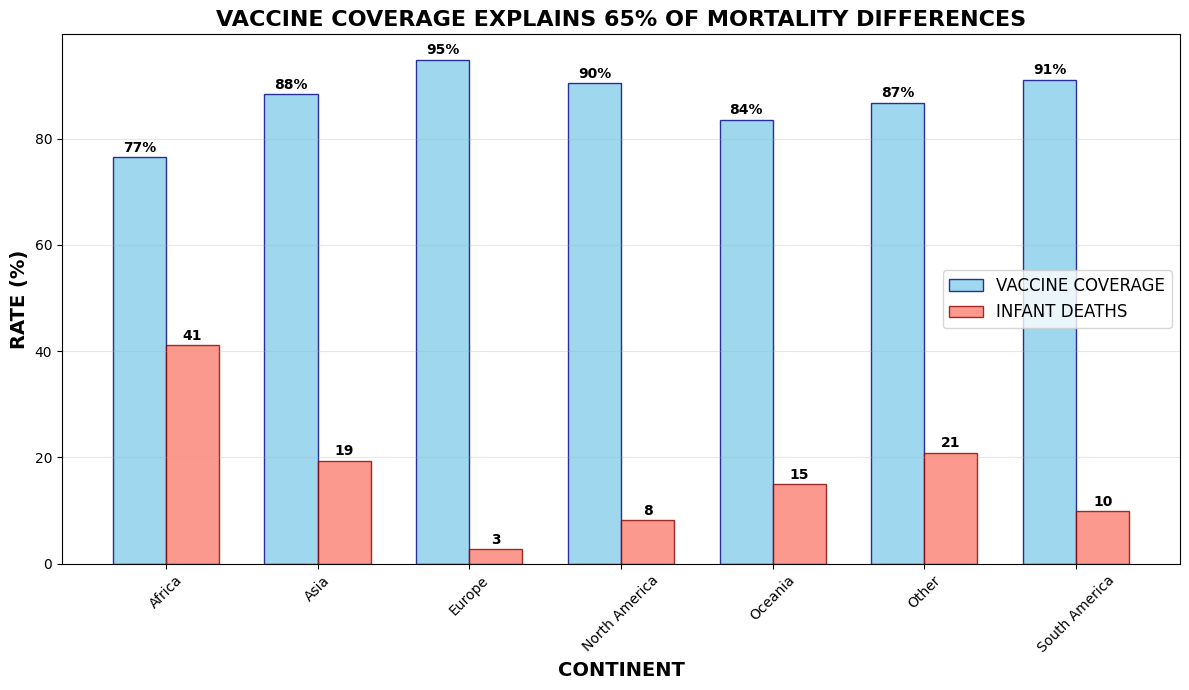

In [79]:
continent_stats = recent_merged .groupby('Continent')[["Measles_1dose", 'Infant_Mortality_Rate']].mean()

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(continent_stats))
width = 0.35

ax.bar(x - width/2, continent_stats["Measles_1dose"], width,
       label='VACCINE COVERAGE', alpha=0.8, color='skyblue', edgecolor='navy')
ax.bar(x + width/2, continent_stats['Infant_Mortality_Rate'], width,
       label='INFANT DEATHS', alpha=0.8, color='salmon', edgecolor='darkred')

ax.set_xlabel('CONTINENT', fontsize=14, fontweight='bold')
ax.set_ylabel('RATE (%)', fontsize=14, fontweight='bold')
ax.set_title('VACCINE COVERAGE EXPLAINS 65% OF MORTALITY DIFFERENCES', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(continent_stats.index, rotation=45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(continent_stats["Measles_1dose"]):
    ax.text(i - width/2, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')
for i, v in enumerate(continent_stats['Infant_Mortality_Rate']):
    ax.text(i + width/2, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# **Specific Country Analysis: India, Nigeria, and San Marino**

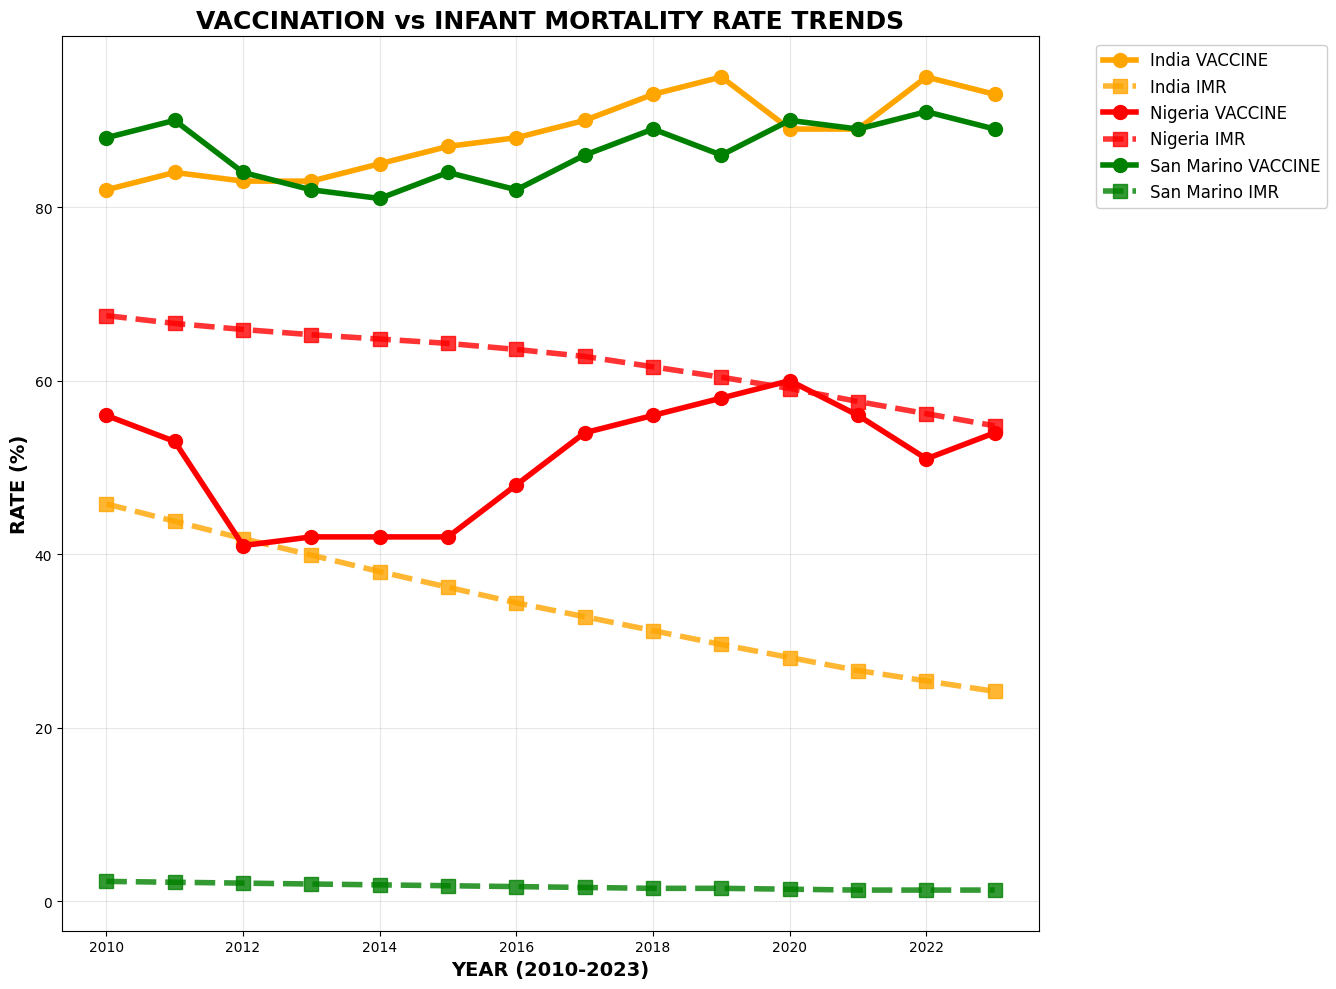

In [82]:
time_countries = ['India', 'Nigeria', 'San Marino']
colors = ['orange', 'red', 'green', 'brown']

plt.figure(figsize=(16, 10))  # Increase figure size for more space

for i, country in enumerate(time_countries):
    data = recent_merged[recent_merged['Country'] == country]
    yearly = data.groupby('Year')[["Measles_1dose", 'Infant_Mortality_Rate']].mean()

    plt.plot(yearly.index, yearly["Measles_1dose"],
             'o-', linewidth=4, markersize=10, label=f'{country} VACCINE', color=colors[i])
    plt.plot(yearly.index, yearly['Infant_Mortality_Rate'],
             's--', linewidth=4, markersize=10, label=f'{country} IMR', color=colors[i], alpha=0.8)

plt.xlabel('YEAR (2010-2023)', fontsize=14, fontweight='bold')
plt.ylabel('RATE (%)', fontsize=14, fontweight='bold')
plt.title('VACCINATION vs INFANT MORTALITY RATE TRENDS', fontsize=18, fontweight='bold')

# Place legend outside the plot area on the upper right
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12, framealpha=0.95)

plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space on right for legend
plt.show()
